# Disaster Detection Pipeline
**Model:** `meta-llama/Llama-3.2-11B-Vision-Instruct`

## Workflow
1. Read tile-pair CSV → for each pre/post tile pair per image:
   - VLM call 1: summarise the **pre** tile (text context)
   - VLM call 2: using pre-summary as context, assess **post** tile → damage level + evidence
   - VLM call 3: extract normalised bounding boxes of damage on **post** tile (JSON)
   - SAM: segment exact damage regions inside those boxes
2. Stitch all tile masks + images back into the full canvas
3. Overlay a **colour-coded heatmap** (green → yellow → orange → red) on the full post-disaster image
4. Display and save one figure per image

> **Note:** The JSON files (`*_pre/post_disaster.json`) contain ground-truth building polygons with damage subtypes — useful for validation but not used during inference.

In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
# Run once; restart kernel afterwards if transformers/PIL were just installed.
!pip -q install -U "transformers>=4.45.0" "accelerate>=0.33.0" "safetensors" "huggingface_hub"
!pip -q install pillow==10.4.0
!pip -q install "bitsandbytes"
!pip -q install matplotlib pandas numpy
!pip -q install git+https://github.com/facebookresearch/segment-anything.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────────
import os, sys, json, re
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from PIL import Image
from transformers import AutoProcessor, MllamaForConditionalGeneration
from huggingface_hub import login

print("Python     :", sys.version)
print("PyTorch    :", torch.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))

Python     : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch    : 2.10.0+cu128
CUDA avail : True
GPU        : NVIDIA A100-SXM4-40GB


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ── Cell 3: Hugging Face login ─────────────────────────────────────────────────
# Llama-3.2 is gated — accept the licence at hf.co/meta-llama first.
login()

In [5]:
# ── Cell 4: Load Llama-3.2-11B-Vision-Instruct ────────────────────────────────
MODEL_ID = "meta-llama/Llama-3.2-11B-Vision-Instruct"

# Use bfloat16 on Ampere+ GPUs (capability >= 8), else float16
dtype = (
    torch.bfloat16
    if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
    else torch.float16
)

model = MllamaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(MODEL_ID)

print("Loaded:", MODEL_ID)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/906 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

...

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `MllamaImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Loaded: meta-llama/Llama-3.2-11B-Vision-Instruct


In [22]:
# ── Cell 5: VLM helper functions ──────────────────────────────────────────────

def run_vlm(image: Image.Image, user_text: str, max_new_tokens: int = 256) -> str:
    """Run Llama-3.2-Vision on a single image + text prompt.
    Returns only the model's generated response (input tokens stripped)."""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": user_text},
            ],
        }
    ]
    prompt = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False
    )
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens)

    # Decode only the newly generated tokens so the input prompt is not echoed
    input_len = inputs["input_ids"].shape[1]
    return processor.decode(output[0][input_len:], skip_special_tokens=True)


def extract_damage_level(text: str) -> str:
    """Parse a damage-level label from free-form VLM output.
    Returns one of: no_damage | minor_damage | major_damage | destroyed."""
    t = text.lower()
    for level in ("destroyed", "major_damage", "minor_damage", "no_damage"):
        if level in t:
            return level
    # Looser keyword fallback
    if any(k in t for k in ("destroy", "collapse", "complet")):
        return "destroyed"
    if any(k in t for k in ("major", "severe", "significant")):
        return "major_damage"
    if any(k in t for k in ("minor", "slight", "small")):
        return "minor_damage"
    return "no_damage"


def parse_regions_strict(text: str, tile_w: int = 512, tile_h: int = 512) -> list:
    """Extract and validate bounding boxes from JSON output.

    Handles two coordinate conventions:
      - Normalised floats  (0.0 – 1.0)  → used as-is
      - Pixel integers     (> 1.5)       → divided by tile_w / tile_h to normalise
    """
    if "{" not in text:
        return []
    # Strip markdown fences; use find (not rfind) to keep the outermost { intact
    text = re.sub(r"```[a-zA-Z]*", "", text).strip()
    s = text[text.find("{"):].strip()
    # Auto-close truncated JSON
    s += "]" * (s.count("[") - s.count("]"))
    s += "}" * (s.count("{") - s.count("}"))
    try:
        obj = json.loads(s)
    except Exception:
        return []

    if isinstance(obj, dict) and "regions" in obj:
        regions = obj["regions"]
    elif isinstance(obj, dict) and "bbox" in obj:
        regions = [obj]
    else:
        return []

    clean = []
    for r in regions:
        bbox = r.get("bbox", [])
        if not (isinstance(bbox, list) and len(bbox) == 4):
            continue
        try:
            x1, y1, x2, y2 = [float(v) for v in bbox]
        except Exception:
            continue
        # Auto-detect pixel coordinates: if any value > 1.5, normalise
        if max(x1, y1, x2, y2) > 1.5:
            x1, x2 = x1 / tile_w, x2 / tile_w
            y1, y2 = y1 / tile_h, y2 / tile_h
        # Clamp to valid range
        x1, y1, x2, y2 = (max(0.0, min(1.0, v)) for v in (x1, y1, x2, y2))
        if x2 <= x1 or y2 <= y1:
            continue
        clean.append({"label": "damage", "bbox": [x1, y1, x2, y2]})
    return clean


print("VLM helpers defined.")

VLM helpers defined.


In [7]:
# ── Cell 6: Download SAM checkpoint (skip if already present) ─────────────────
SAM_CHECKPOINT = "sam_vit_h_4b8939.pth"
SAM_URL        = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
SAM_TYPE       = "vit_h"


def _download_progress(block_num, block_size, total_size):
    if total_size > 0:
        pct          = min(block_num * block_size * 100 // total_size, 100)
        downloaded   = block_num * block_size / 1e6
        total        = total_size / 1e6
        sys.stdout.write(f"\r  {pct:3d}%  {downloaded:.0f} / {total:.0f} MB")
        sys.stdout.flush()


if not Path(SAM_CHECKPOINT).exists():
    print(f"Downloading SAM checkpoint (~2.4 GB) → {SAM_CHECKPOINT}")
    urllib.request.urlretrieve(SAM_URL, SAM_CHECKPOINT, _download_progress)
    print("\nDownload complete.")
else:
    print(f"SAM checkpoint found: {SAM_CHECKPOINT}")

  100%  2565 / 2565 MB
Download complete.


In [8]:
# ── Cell 7: Load SAM ──────────────────────────────────────────────────────────
from segment_anything import sam_model_registry, SamPredictor

sam = sam_model_registry[SAM_TYPE](checkpoint=SAM_CHECKPOINT)
sam.to("cuda" if torch.cuda.is_available() else "cpu")
predictor = SamPredictor(sam)
print("SAM loaded.")

SAM loaded.


In [49]:
# ── Cell 8: Tile + overlay utilities ──────────────────────────────────────────

# Damage level → (R, G, B) colour and overlay alpha
DAMAGE_COLORS = {
    "no_damage":    (  0, 200,   0),   # green
    "minor_damage": (255, 220,   0),   # yellow
    "major_damage": (255, 120,   0),   # orange
    "destroyed":    (220,   0,   0),   # red
}
DAMAGE_ALPHA = {
    "no_damage":     80,
    "minor_damage": 110,
    "major_damage": 155,
    "destroyed":    200,
}


def parse_tile_position(tile_filename: str):
    """Return (row, col) ints from filenames like 'tile_r001_c002.png'."""
    m = re.match(r"tile_r(\d+)_c(\d+)", tile_filename)
    return (int(m.group(1)), int(m.group(2))) if m else (0, 0)


def run_sam_on_tile(post_tile_np: np.ndarray, regions: list) -> np.ndarray:
    """Run SAM on one tile with normalised bbox regions.
    Returns a boolean H×W mask covering all detected damage areas."""
    H, W = post_tile_np.shape[:2]
    predictor.set_image(post_tile_np)
    combined = np.zeros((H, W), dtype=bool)
    for r in regions:
        x1, y1, x2, y2 = r["bbox"]
        box = np.array([x1 * W, y1 * H, x2 * W, y2 * H])
        mask, _, _ = predictor.predict(box=box, multimask_output=False)
        combined |= mask[0]
    return combined


def build_tile_overlay(mask: np.ndarray, damage_level: str,
                       tile_h: int, tile_w: int) -> np.ndarray:
    """Return an RGBA uint8 array (tile_h × tile_w × 4) for one tile's heatmap layer.
    SAM mask pixels get full alpha; if SAM found nothing the whole tile is tinted
    at half alpha so the predicted class is still visible."""
    color = DAMAGE_COLORS.get(damage_level, (128, 128, 128))
    alpha = DAMAGE_ALPHA.get(damage_level, 0)
    overlay = np.zeros((tile_h, tile_w, 4), dtype=np.uint8)
    if mask is not None and np.any(mask):
        overlay[mask] = [*color, alpha]
    else:
        overlay[:, :] = [*color, max(40, alpha // 2)]
    return overlay


def stitch_full_image(tile_images: dict, n_rows: int, n_cols: int,
                      tile_h: int, tile_w: int) -> Image.Image:
    """Stitch {(row, col): PIL.Image} into one full RGB canvas."""
    canvas = Image.new("RGB", (n_cols * tile_w, n_rows * tile_h), (0, 0, 0))
    for (r, c), img in tile_images.items():
        canvas.paste(img, (c * tile_w, r * tile_h))
    return canvas


def stitch_overlay(tile_overlays: dict, n_rows: int, n_cols: int,
                   tile_h: int, tile_w: int) -> Image.Image:
    """Stitch {(row, col): RGBA ndarray} into one full RGBA canvas."""
    canvas = Image.new("RGBA", (n_cols * tile_w, n_rows * tile_h), (0, 0, 0, 0))
    for (r, c), arr in tile_overlays.items():
        canvas.paste(Image.fromarray(arr, "RGBA"), (c * tile_w, r * tile_h))
    return canvas


print("Tile utilities defined.")

Tile utilities defined.


In [43]:
# ── Cell 8.5: Building data utilities (JSON integration) ─────────────────────────
from PIL import ImageDraw

# Maps JSON subtype strings → the same labels the VLM produces
GT_LABEL_MAP = {
    "no-damage":     "no_damage",
    "minor-damage":  "minor_damage",
    "major-damage":  "major_damage",
    "destroyed":     "destroyed",
    "un-classified": None,   # excluded from accuracy metrics
}


def load_building_data(json_path: Path) -> list:
    """Load building polygons + ground-truth labels from a *_post_disaster.json.

    Returns a list of dicts — one per building:
        uid       : str
        gt_label  : str | None   (None = un-classified, skip in metrics)
        polygon   : list[(x, y)] in FULL-image pixel coords
        bbox      : [xmin, ymin, xmax, ymax]
    """
    with open(json_path) as f:
        data = json.load(f)
    buildings = []
    for feat in data["features"]["xy"]:
        uid     = feat["properties"]["uid"]
        subtype = feat["properties"].get("subtype", "un-classified")
        gt      = GT_LABEL_MAP.get(subtype)
        polygon = _parse_wkt_polygon(feat["wkt"])
        if len(polygon) < 3:
            continue
        xs, ys = zip(*polygon)
        buildings.append({
            "uid":      uid,
            "gt_label": gt,
            "polygon":  polygon,
            "bbox":     [min(xs), min(ys), max(xs), max(ys)],
        })
    return buildings


def _parse_wkt_polygon(wkt: str) -> list:
    """'POLYGON ((x1 y1, x2 y2, ...))' → list of (x, y) floats."""
    s = wkt[wkt.find("(") + 1 : wkt.rfind(")")].strip(" ()")
    pairs = []
    for token in s.split(","):
        parts = token.strip().split()
        if len(parts) == 2:
            pairs.append((float(parts[0]), float(parts[1])))
    return pairs


def get_buildings_in_tile(buildings: list, tile_row: int, tile_col: int,
                           tile_h: int, tile_w: int) -> list:
    """Return buildings whose centroid falls in tile (tile_row, tile_col).

    Tile → full-image pixel region:
        x ∈ [tile_col*tile_w, (tile_col+1)*tile_w)
        y ∈ [tile_row*tile_h, (tile_row+1)*tile_h)

    Each returned dict gains:
        local_poly : polygon in tile-local pixels
        local_bbox : [x0, y0, x1, y1] clamped to tile
        norm_bbox  : same but normalised to [0, 1] — ready for SAM
    """
    ox = tile_col * tile_w
    oy = tile_row * tile_h
    result = []
    for b in buildings:
        bx0, by0, bx1, by1 = b["bbox"]
        cx, cy = (bx0 + bx1) / 2, (by0 + by1) / 2
        if not (ox <= cx < ox + tile_w and oy <= cy < oy + tile_h):
            continue
        lx0 = max(0.0,           bx0 - ox)
        ly0 = max(0.0,           by0 - oy)
        lx1 = min(float(tile_w), bx1 - ox)
        ly1 = min(float(tile_h), by1 - oy)
        result.append({
            **b,
            "local_poly": [(px - ox, py - oy) for px, py in b["polygon"]],
            "local_bbox": [lx0, ly0, lx1, ly1],
            "norm_bbox":  [lx0 / tile_w, ly0 / tile_h, lx1 / tile_w, ly1 / tile_h],
        })
    return result


def draw_building_polygons(arr: np.ndarray, buildings: list,
                            pred_label: str) -> np.ndarray:
    """Draw predicted-damage polygons onto an RGBA tile array.

    The polygon color always reflects the predicted damage level.
    Green is reserved for no_damage.
    """
    img  = Image.fromarray(arr, "RGBA")
    draw = ImageDraw.Draw(img, "RGBA")
    fill_rgb   = DAMAGE_COLORS.get(pred_label, (128, 128, 128))
    fill_alpha = max(65, DAMAGE_ALPHA.get(pred_label, 90) // 2)
    outline    = (*fill_rgb, 255)

    for b in buildings:
        poly = [(float(x), float(y)) for x, y in b["local_poly"]]
        if len(poly) < 3:
            continue
        draw.polygon(poly, fill=(*fill_rgb, fill_alpha), outline=outline)

    return np.array(img)


print("Building data utilities defined.")

Building data utilities defined.


In [50]:
# ── Cell 9: Configuration ─────────────────────────────────────────────────────
# ── Colab / local path setup ─────────────────────────────────────────────────
try:
    import google.colab
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

if ON_COLAB:
    BASE_DIR = Path("/content")
    # ── Google Drive alternative (uncomment if needed) ────────────────────────
    # from google.colab import drive
    # drive.mount("/content/drive")
    # BASE_DIR = Path("/content/drive/MyDrive/DisasterDetectionVLMStuff")
else:
    BASE_DIR = Path(".")

TILE_CSV   = BASE_DIR / "tile_pairs.csv"
OUTPUT_DIR = BASE_DIR / "results"
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(TILE_CSV)
# Normalise Windows backslashes → forward slashes for Linux/Colab compatibility
df["pre_disaster"]  = df["pre_disaster"].str.strip().str.replace("\\", "/", regex=False)
df["post_disaster"] = df["post_disaster"].str.strip().str.replace("\\", "/", regex=False)

# ── Load JSON building annotations ───────────────────────────────────────────
# Each JSON contains pixel-space building polygons + ground-truth damage labels.
# Used to: (a) supply SAM with precise building bboxes, (b) evaluate VLM accuracy.
building_data = {}   # {image_name: [building_dict, ...]}
for img_name in df["image_name"].unique():
    stem      = img_name.replace(".png", "")
    json_path = BASE_DIR / f"{stem}_post_disaster.json"
    if json_path.exists():
        building_data[img_name] = load_building_data(json_path)
        print(f"  Loaded {len(building_data[img_name]):3d} buildings  ← {json_path.name}")
    else:
        building_data[img_name] = []
        print(f"  No JSON found for {img_name} — building annotations unavailable")

print(df.head(6))
print(f"\nTotal tile pairs : {len(df)}")
print(f"Unique images    : {df['image_name'].nunique()}")
print(f"BASE_DIR         : {BASE_DIR.resolve()}")

  Loaded  80 buildings  ← hurricane-matthew_00000011_post_disaster.json
  Loaded 335 buildings  ← hurricane-matthew_00000027_post_disaster.json
                       image_name                tile  \
0  hurricane-matthew_00000011.png  tile_r000_c000.png   
1  hurricane-matthew_00000011.png  tile_r000_c001.png   
2  hurricane-matthew_00000011.png  tile_r000_c002.png   
3  hurricane-matthew_00000011.png  tile_r001_c000.png   
4  hurricane-matthew_00000011.png  tile_r001_c001.png   
5  hurricane-matthew_00000011.png  tile_r001_c002.png   

                                        pre_disaster  \
0  cropped-pre-disaster-images/hurricane-matthew_...   
1  cropped-pre-disaster-images/hurricane-matthew_...   
2  cropped-pre-disaster-images/hurricane-matthew_...   
3  cropped-pre-disaster-images/hurricane-matthew_...   
4  cropped-pre-disaster-images/hurricane-matthew_...   
5  cropped-pre-disaster-images/hurricane-matthew_...   

                                       post_disaster  
0  cropp

In [51]:
# ── Cell 10: Main processing loop ─────────────────────────────────────────────
# Per tile:
#   Validity check  : skip if >70 % of post pixels are near-black (no-data)
#   VLM call 1      : pre-tile scene summary → text context
#   VLM call 2      : post-tile damage assessment → damage level
#   JSON buildings  : look up building footprints that fall in this tile
#                     → use their bboxes as SAM prompts (replaces VLM box call)
#   VLM call 3 (fb) : only used when no JSON buildings found for this tile
#   SAM             : segment damage regions → boolean H×W mask

BLACK_THRESHOLD  = 15
BLACK_SKIP_RATIO = 0.70

WHOLE_TILE_REGION = [{"label": "damage", "bbox": [0.02, 0.02, 0.98, 0.98]}]

BOX_PROMPT = (
    "Return ONLY JSON. No markdown. No extra text.\n\n"
    'Output MUST be exactly this shape:\n'
    '{"regions":[{"label":"damage","bbox":[x1,y1,x2,y2]}]}\n\n'
    "Rules:\n"
    '- label MUST be exactly "damage"\n'
    "- bbox values MUST be decimals between 0.0 and 1.0\n"
    "- x2 > x1 and y2 > y1\n"
    "- Return 1 to 3 regions.\n"
    "- If unsure, return 1 region covering the most likely damaged area."
)

all_results = {}

for image_name, group in df.groupby("image_name"):
    print(f"\n{'='*62}")
    print(f"  Image: {image_name}")
    print(f"{'='*62}")

    # Full grid extent from ALL tiles (skipped tiles leave black canvas regions)
    _positions  = [parse_tile_position(r["tile"]) for _, r in group.iterrows()]
    full_n_rows = max(r for r, c in _positions) + 1
    full_n_cols = max(c for r, c in _positions) + 1

    post_imgs      = {}   # {(r,c): PIL.Image}
    masks          = {}   # {(r,c): np.ndarray bool}
    damage_levels  = {}   # {(r,c): str}
    tile_buildings = {}   # {(r,c): [building_dict with local coords]}

    for _, row in group.iterrows():
        tile_name = row["tile"]
        rc        = parse_tile_position(tile_name)
        pre_path  = BASE_DIR / Path(row["pre_disaster"])
        post_path = BASE_DIR / Path(row["post_disaster"])

        if not pre_path.exists() or not post_path.exists():
            print(f"  [SKIP] {tile_name} — file(s) not found")
            continue

        pre_img  = Image.open(pre_path).convert("RGB")
        post_img = Image.open(post_path).convert("RGB")

        # ── Validity check ────────────────────────────────────────────────────
        post_arr       = np.array(post_img)
        black_fraction = np.all(post_arr <= BLACK_THRESHOLD, axis=2).mean()
        if black_fraction >= BLACK_SKIP_RATIO:
            print(f"  [SKIP] {tile_name} — {100*black_fraction:.0f}% black (no-data)")
            continue

        tile_h, tile_w = post_arr.shape[:2]
        tile_np        = post_arr
        post_imgs[rc]  = post_img

        print(f"\n  Tile {tile_name}  (r={rc[0]}, c={rc[1]})  [{100*black_fraction:.0f}% black]")

        # ── Step 1: Pre-tile scene summary ────────────────────────────────────
        pre_summary = run_vlm(
            pre_img,
            "Briefly describe what buildings, roads, and terrain are visible "
            "in this aerial image. Be concise (2 sentences).",
            max_new_tokens=128,
        )

        # ── Step 2: Post-tile damage assessment ───────────────────────────────
        pair_prompt = (
            "You are doing change detection for disaster damage assessment.\n\n"
            f"PRE image description:\n{pre_summary}\n\n"
            "Now look at the POST-disaster image and answer:\n"
            "1) What changed compared to the PRE scene?\n"
            "2) Classify overall damage: no_damage / minor_damage / major_damage / destroyed\n"
            "3) Give 3 short evidence bullets based only on visible cues in the POST image."
        )
        damage_result = run_vlm(post_img, pair_prompt, max_new_tokens=256)
        damage_level  = extract_damage_level(damage_result)
        damage_levels[rc] = damage_level
        print(f"    Damage level  : {damage_level}")

        # ── Step 3: Map JSON buildings to this tile ───────────────────────────
        # These building footprints come from the ground-truth JSON and are far
        # more accurate as SAM prompts than VLM-predicted bounding boxes.
        tile_blds = get_buildings_in_tile(
            building_data.get(image_name, []), rc[0], rc[1], tile_h, tile_w
        )
        tile_buildings[rc] = tile_blds
        print(f"    JSON buildings: {len(tile_blds)}")

        # ── Step 4: Determine SAM regions ─────────────────────────────────────
        if tile_blds:
            # Primary: use JSON building bboxes directly
            sam_regions = [{"label": "damage", "bbox": b["norm_bbox"]}
                           for b in tile_blds]
        elif damage_level != "no_damage":
            # Fallback: ask VLM for boxes (only when no JSON buildings available)
            boxes_raw = run_vlm(post_img, BOX_PROMPT, max_new_tokens=120)
            print(f"    Raw VLM boxes : {boxes_raw[:200]!r}")
            sam_regions = parse_regions_strict(boxes_raw, tile_w=tile_w, tile_h=tile_h)
            print(f"    Parsed boxes  : {len(sam_regions)}")
            if not sam_regions:
                print("    [FALLBACK]    Using whole-tile box for SAM")
                sam_regions = WHOLE_TILE_REGION
        else:
            sam_regions = []

        # ── Step 5: SAM segmentation ──────────────────────────────────────────
        if sam_regions:
            combined_mask = run_sam_on_tile(tile_np, sam_regions)
            print(f"    SAM coverage  : {100 * combined_mask.mean():.1f}%")
        else:
            combined_mask = np.zeros((tile_h, tile_w), dtype=bool)
        masks[rc] = combined_mask

        # Log GT distribution for this tile's buildings
        if tile_blds:
            from collections import Counter
            gt_counts = Counter(b["gt_label"] for b in tile_blds if b["gt_label"])
            print(f"    GT (this tile): {dict(gt_counts)}")

    all_results[image_name] = {
        "post_imgs":      post_imgs,
        "masks":          masks,
        "damage_levels":  damage_levels,
        "tile_buildings": tile_buildings,
        "n_rows":         full_n_rows,
        "n_cols":         full_n_cols,
    }

print("\n\nAll tiles processed.")


  Image: hurricane-matthew_00000011.png

  Tile tile_r000_c000.png  (r=0, c=0)  [0% black]
    Damage level  : major_damage
    JSON buildings: 2
    SAM coverage  : 0.2%
    GT (this tile): {'minor_damage': 1}

  Tile tile_r000_c001.png  (r=0, c=1)  [0% black]
    Damage level  : major_damage
    JSON buildings: 20
    SAM coverage  : 2.4%
    GT (this tile): {'no_damage': 8, 'minor_damage': 7, 'major_damage': 2}
  [SKIP] tile_r000_c002.png — file(s) not found

  Tile tile_r001_c000.png  (r=1, c=0)  [0% black]
    Damage level  : no_damage
    JSON buildings: 1
    SAM coverage  : 0.1%
    GT (this tile): {'minor_damage': 1}

  Tile tile_r001_c001.png  (r=1, c=1)  [0% black]
    Damage level  : no_damage
    JSON buildings: 57
    SAM coverage  : 9.7%
    GT (this tile): {'no_damage': 26, 'minor_damage': 30}
  [SKIP] tile_r001_c002.png — file(s) not found
  [SKIP] tile_r002_c000.png — file(s) not found
  [SKIP] tile_r002_c001.png — file(s) not found
  [SKIP] tile_r002_c002.png — file

/tmp/ipykernel_1544/2679718558.py:95: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img  = Image.fromarray(arr, "RGBA")
/tmp/ipykernel_1544/170753693.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  canvas.paste(Image.fromarray(arr, "RGBA"), (c * tile_w, r * tile_h))


Saved → /content/results/heatmap_hurricane-matthew_00000011.png


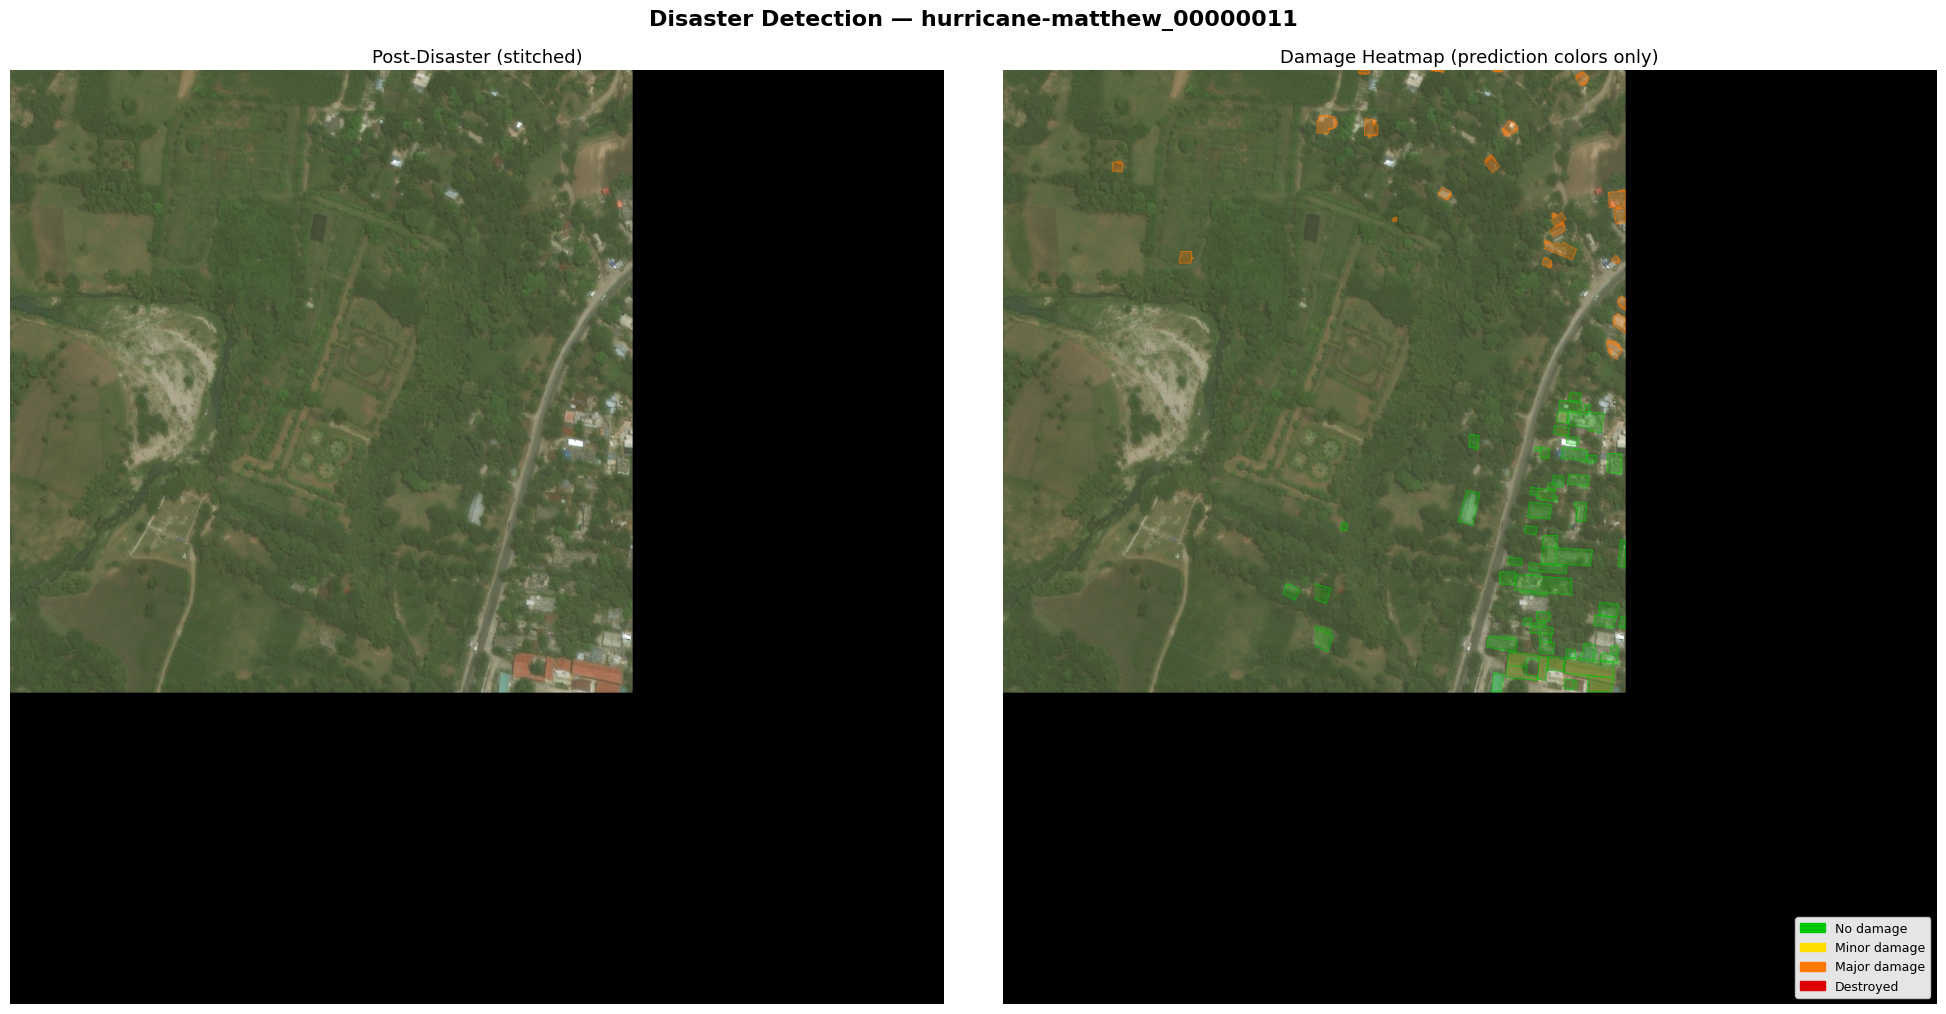

Saved → /content/results/heatmap_hurricane-matthew_00000027.png


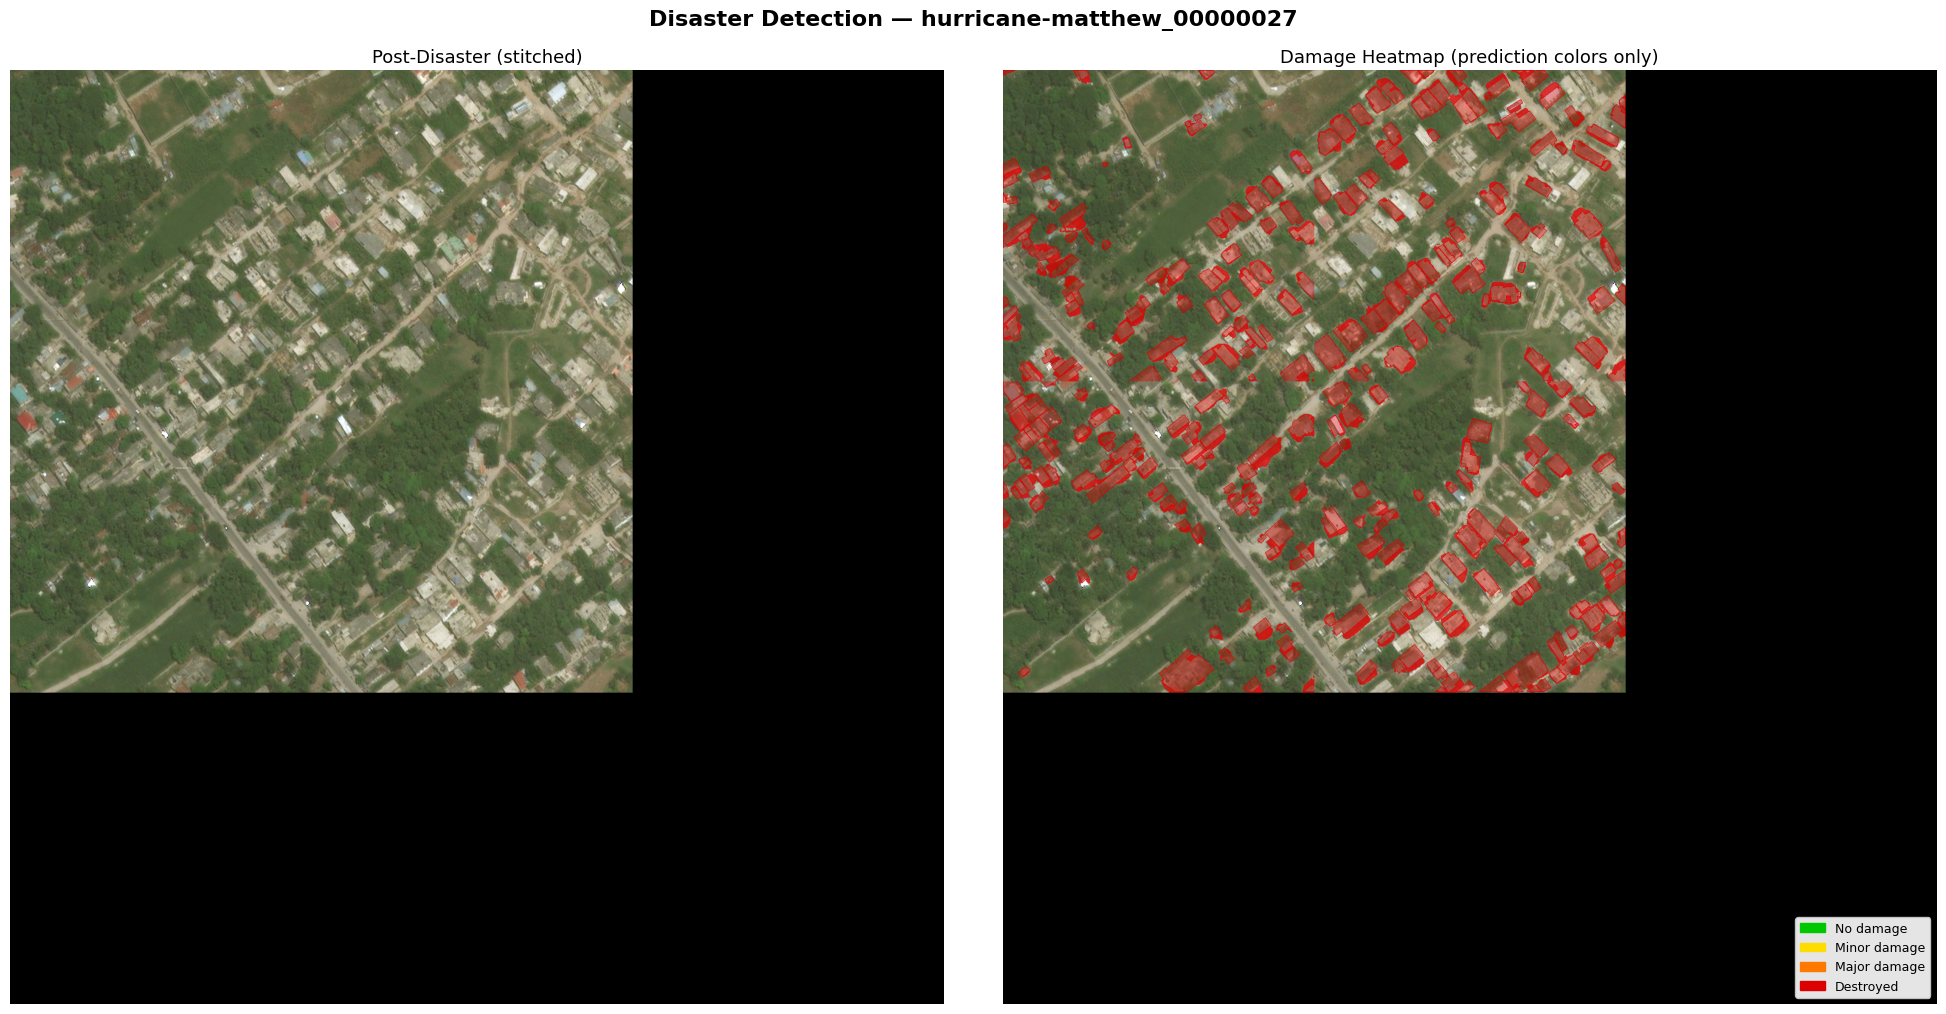

In [52]:
# ── Cell 12: Stitch tiles + render heatmap with damage-level polygon overlays ──

legend_patches = [
    mpatches.Patch(color=tuple(v / 255 for v in DAMAGE_COLORS["no_damage"]),    label="No damage"),
    mpatches.Patch(color=tuple(v / 255 for v in DAMAGE_COLORS["minor_damage"]), label="Minor damage"),
    mpatches.Patch(color=tuple(v / 255 for v in DAMAGE_COLORS["major_damage"]), label="Major damage"),
    mpatches.Patch(color=tuple(v / 255 for v in DAMAGE_COLORS["destroyed"]),    label="Destroyed"),
]

for image_name, data in all_results.items():
    post_imgs      = data["post_imgs"]
    masks          = data["masks"]
    damage_levels  = data["damage_levels"]
    tile_blds_map  = data.get("tile_buildings", {})

    if not post_imgs:
        print(f"No valid tiles for {image_name} — skipping.")
        continue

    n_rows = data["n_rows"]
    n_cols = data["n_cols"]

    sample         = next(iter(post_imgs.values()))
    tile_w, tile_h = sample.size

    full_post = stitch_full_image(post_imgs, n_rows, n_cols, tile_h, tile_w)

    tile_overlays = {}
    for rc in post_imgs:
        d_level = damage_levels.get(rc, "no_damage")
        arr     = build_tile_overlay(masks.get(rc), d_level, tile_h, tile_w)
        blds    = tile_blds_map.get(rc, [])
        if blds:
            arr = draw_building_polygons(arr, blds, d_level)
        tile_overlays[rc] = arr

    full_overlay = stitch_overlay(tile_overlays, n_rows, n_cols, tile_h, tile_w)
    composite = Image.alpha_composite(full_post.convert("RGBA"), full_overlay)

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    axes[0].imshow(full_post)
    axes[0].set_title("Post-Disaster (stitched)", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(composite)
    axes[1].set_title("Damage Heatmap (prediction colors only)", fontsize=13)
    axes[1].legend(handles=legend_patches, loc="lower right", fontsize=9, framealpha=0.9)
    axes[1].axis("off")

    base = image_name.replace(".png", "")
    plt.suptitle(f"Disaster Detection — {base}", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()

    out_path = OUTPUT_DIR / f"heatmap_{base}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved → {out_path}")
    plt.show()

In [53]:
# ── Cell 12: Summary tables ────────────────────────────────────────────────────

# ── Tile-level summary ────────────────────────────────────────────────────────
rows = []
for image_name, data in all_results.items():
    for (r, c), level in data["damage_levels"].items():
        mask = data["masks"].get((r, c))
        pct  = round(100.0 * mask.sum() / mask.size, 2) if mask is not None and mask.size > 0 else 0.0
        n_blds = len(data.get("tile_buildings", {}).get((r, c), []))
        rows.append({
            "image":          image_name,
            "tile_row":       r,
            "tile_col":       c,
            "damage_level":   level,
            "sam_coverage%":  pct,
            "json_buildings": n_blds,
        })

summary_df = pd.DataFrame(rows).sort_values(["image", "tile_row", "tile_col"])
print("── Tile-level summary ──────────────────────────────────────────────────")
print(summary_df.to_string(index=False))

# ── Building-level evaluation (vs ground truth) ───────────────────────────────
bld_rows = []
for image_name, data in all_results.items():
    for rc, blds in data.get("tile_buildings", {}).items():
        d_level = data["damage_levels"].get(rc, "no_damage")
        for b in blds:
            gt = b["gt_label"]    # already normalised by load_building_data
            bld_rows.append({
                "image":      image_name,
                "tile":       f"r{rc[0]}c{rc[1]}",
                "uid":        b["uid"][:10] + "…",
                "gt_label":   gt if gt else "un-classified",
                "pred_label": d_level,
                "correct":    (gt == d_level) if gt else None,
            })

if bld_rows:
    bld_df   = pd.DataFrame(bld_rows)
    eval_df  = bld_df[bld_df["gt_label"] != "un-classified"].copy()

    print("\n── Building-level predictions vs ground truth ──────────────────────────")
    print(bld_df.sort_values(["image", "tile"]).to_string(index=False))

    if not eval_df.empty:
        accuracy = (eval_df["pred_label"] == eval_df["gt_label"]).mean()
        per_class = eval_df.groupby("gt_label").apply(
            lambda g: (g["pred_label"] == g["gt_label"]).mean()
        ).rename("accuracy")
        print(f"\nOverall building-level accuracy: {accuracy:.1%}  "
              f"(N={len(eval_df)} labelled buildings)")
        print(per_class.to_string())
    else:
        print("\n(No labelled buildings to evaluate.)")
else:
    print("\n(No building data loaded — only tile-level summary available.)")

── Tile-level summary ──────────────────────────────────────────────────
                         image  tile_row  tile_col damage_level  sam_coverage%  json_buildings
hurricane-matthew_00000011.png         0         0 major_damage           0.19               2
hurricane-matthew_00000011.png         0         1 major_damage           2.42              20
hurricane-matthew_00000011.png         1         0    no_damage           0.10               1
hurricane-matthew_00000011.png         1         1    no_damage           9.68              57
hurricane-matthew_00000027.png         0         0    destroyed          13.59              82
hurricane-matthew_00000027.png         0         1    destroyed          20.25              82
hurricane-matthew_00000027.png         1         0    destroyed          12.90              83
hurricane-matthew_00000027.png         1         1    destroyed          17.72              88

── Building-level predictions vs ground truth ─────────────────────────

/tmp/ipykernel_1544/3458347979.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_class = eval_df.groupby("gt_label").apply(
